In [5]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

**Import modules**

In [6]:
!pip install -q faiss-cpu sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 51.9 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 59.2 MB/s eta 0:00:0000:01:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is inc

In [7]:
import os
import re
import gc
import string
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import faiss
from sentence_transformers import SentenceTransformer, CrossEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score

import torch
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu only")

GPU: Tesla T4


**Config**

In [8]:
LABELS = ['A', 'B', 'C', 'D', 'E']
L2I = {l: i for i, l in enumerate(LABELS)}

EMBED_MODEL = 'all-MiniLM-L6-v2'
CROSS_MODEL = 'cross-encoder/ms-marco-MiniLM-L-6-v2'

TOP_K = 10          
RERANK_KEEP = 3     
N_FOLDS = 5
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

**Loading data**

In [9]:
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
sample = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")

for df in [train, test]:
    for col in ['prompt'] + LABELS:
        df[col] = df[col].fillna("")

train = train.reset_index(drop=True)
test = test.reset_index(drop=True)
y_true = np.array([L2I[a] for a in train['answer']])

print("Train:", train.shape, " Test:", test.shape)

Train: (2000, 8)  Test: (500, 7)


**Metrics**

In [10]:
def map_at_3(probs, targets):
    top3 = np.argsort(-probs, axis=1)[:, :3]
    score = 0.0
    for i in range(len(targets)):
        for rank in range(3):
            if top3[i][rank] == targets[i]:
                score += 1.0 / (rank + 1)
                break
    return score / len(targets)


def all_metrics(probs, targets):
    preds = probs.argmax(axis=1)
    return {"acc": accuracy_score(targets, preds),
            "f1": f1_score(targets, preds, average='macro'),
            "map3": map_at_3(probs, targets)}

print("Random MAP@3:", round((1 + 1/2 + 1/3) / 5, 4))

Random MAP@3: 0.3667


**EDA - confirming how repetitive this dataset is**

In [11]:
# vocabulary of the prompts
def clean_for_vocab(t):
    t = str(t).lower()
    t = t.translate(str.maketrans('', '', string.punctuation))
    return t.split()

vocab = set()
for p in train['prompt']:
    vocab.update(clean_for_vocab(p))

print("Rows in train:", len(train))
print("Unique words across all prompts:", len(vocab))
print()

tv_all = TfidfVectorizer(stop_words='english')
combined = train['prompt'].tolist()
for c in LABELS:
    combined += train[c].tolist()
tv_all.fit(combined)
print("TF-IDF features for prompts + options:", len(tv_all.vocabulary_))
print()
print("A vocabulary this small means the questions repeat a lot.")
print("That is why retrieval works better than a neural model here.")

Rows in train: 2000
Unique words across all prompts: 859

TF-IDF features for prompts + options: 2762

A vocabulary this small means the questions repeat a lot.
That is why retrieval works better than a neural model here.


answer
A    369
B    490
C    459
D    358
E    324
Name: count, dtype: int64

Most frequent + least frequent = 814


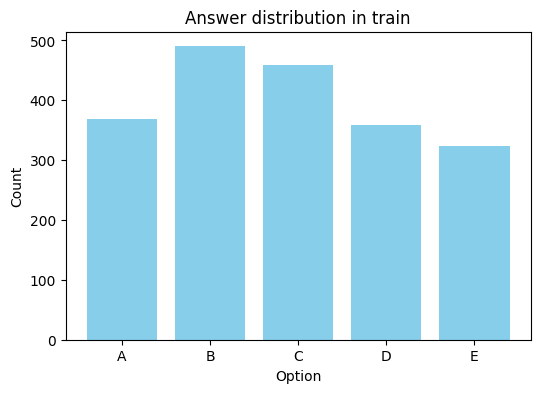

Majority-class baseline MAP@3: 0.4213


In [12]:
# answer distribution
counts = train['answer'].value_counts().reindex(LABELS, fill_value=0)
print(counts)
print()
print("Most frequent + least frequent =", counts.max() + counts.min())

plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values, color='skyblue')
plt.title("Answer distribution in train")
plt.xlabel("Option")
plt.ylabel("Count")
plt.show()

# majority class baseline
order = counts.sort_values(ascending=False).index.tolist()
maj_probs = np.zeros((len(train), 5))
for rank, letter in enumerate(order):
    maj_probs[:, L2I[letter]] = 5 - rank
print("Majority-class baseline MAP@3:", round(map_at_3(maj_probs, y_true), 4))

In [13]:
# the milestone 1 result: ranking options by tf-idf similarity to the prompt
sim_probs = np.zeros((len(train), 5))
for i, r in train.iterrows():
    texts = [str(r['prompt'])] + [str(r[c]) for c in LABELS]
    try:
        v = tv_all.transform(texts)
        sim_probs[i] = cosine_similarity(v[0:1], v[1:])[0]
    except Exception:
        sim_probs[i] = 0.2

print("TF-IDF prompt-vs-option pipeline MAP@3:", round(map_at_3(sim_probs, y_true), 4))
print("Majority baseline was               :", round(map_at_3(maj_probs, y_true), 4))
print()
print("The similarity pipeline is WORSE than guessing the majority class.")
print("The correct option does not simply share words with the prompt,")
print("so I need a knowledge base instead of direct similarity.")

TF-IDF prompt-vs-option pipeline MAP@3: 0.3082
Majority baseline was               : 0.4213

The similarity pipeline is WORSE than guessing the majority class.
The correct option does not simply share words with the prompt,
so I need a knowledge base instead of direct similarity.


**Build the knowledge base**

In [14]:
kb = []
for _, row in train.iterrows():
    kb.append(str(row[row['answer']]))

print("KB size:", len(kb))
print()
print("Examples:")
for t in kb[:3]:
    print(" -", t[:120])

# how many KB entries are duplicates of each other
print()
print("Unique KB entries:", len(set(kb)), "out of", len(kb))

KB size: 2000

Examples:
 - Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is 
 - Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies s
 - Reddening

Unique KB entries: 313 out of 2000


In [15]:
print("Loading embedding model")
embedder = SentenceTransformer(EMBED_MODEL)

print("Embedding the KB")
kb_emb = embedder.encode(kb, batch_size=128, show_progress_bar=True,
                         convert_to_numpy=True, normalize_embeddings=True).astype(np.float32)

# inner product on normalised vectors = cosine similarity
index = faiss.IndexFlatIP(kb_emb.shape[1])
index.add(kb_emb)
print("FAISS index:", index.ntotal, "vectors, dim", kb_emb.shape[1])

Loading embedding model


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding the KB


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

FAISS index: 2000 vectors, dim 384


**Embed the prompts and the options**

In [16]:
train_prompt_emb = embedder.encode(train['prompt'].astype(str).tolist(),
                                   batch_size=128, show_progress_bar=True,
                                   convert_to_numpy=True,
                                   normalize_embeddings=True).astype(np.float32)

test_prompt_emb = embedder.encode(test['prompt'].astype(str).tolist(),
                                  batch_size=128, show_progress_bar=True,
                                  convert_to_numpy=True,
                                  normalize_embeddings=True).astype(np.float32)


def embed_options(df):
    flat = [str(r[c]) for _, r in df.iterrows() for c in LABELS]
    e = embedder.encode(flat, batch_size=256, show_progress_bar=True,
                        convert_to_numpy=True, normalize_embeddings=True).astype(np.float32)
    return e.reshape(len(df), 5, -1)

print("Embedding options")
train_opt_emb = embed_options(train)
test_opt_emb = embed_options(test)

print("prompt emb:", train_prompt_emb.shape, " option emb:", train_opt_emb.shape)

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Embedding options


Batches:   0%|          | 0/40 [00:00<?, ?it/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

prompt emb: (2000, 384)  option emb: (2000, 5, 384)


**Retrieval quality check**

In [17]:
def retrieve(prompt_emb, exclude_self=False, top_k=TOP_K):
    # ask for extra results so I can drop the self-match and still have top_k
    k = top_k + (1 if exclude_self else 0)
    scores, idxs = index.search(prompt_emb, k)

    if exclude_self:
        clean_idx = []
        clean_sc = []
        for i in range(len(idxs)):
            keep_i, keep_s = [], []
            for j, s in zip(idxs[i], scores[i]):
                if j == i:          # this row's own answer - skip it
                    continue
                keep_i.append(j)
                keep_s.append(s)
            clean_idx.append(keep_i[:top_k])
            clean_sc.append(keep_s[:top_k])
        return np.array(clean_sc), np.array(clean_idx)

    return scores, idxs


tr_scores, tr_idxs = retrieve(train_prompt_emb, exclude_self=True)

# hit rate: is the correct answer text among the retrieved documents?
hits_5 = 0
hits_10 = 0
for i in range(len(train)):
    correct_text = str(train.iloc[i][train.iloc[i]['answer']])
    docs = [kb[j] for j in tr_idxs[i]]
    if correct_text in docs[:5]:
        hits_5 += 1
    if correct_text in docs[:10]:
        hits_10 += 1

print("Hit rate @5 (self excluded) :", round(hits_5 / len(train) * 100, 1), "%")
print("Hit rate @10 (self excluded):", round(hits_10 / len(train) * 100, 1), "%")
print()
print("Milestone 3 Q7 reported 73% at k=5, but that INCLUDED the row's own answer.")
print("The numbers above are the honest version.")

Hit rate @5 (self excluded) : 70.1 %
Hit rate @10 (self excluded): 76.8 %

Milestone 3 Q7 reported 73% at k=5, but that INCLUDED the row's own answer.
The numbers above are the honest version.


**Turning retrieved documents into option scores**

In [18]:
def score_bi_encoder(prompt_idx_scores, prompt_idx_ids, opt_emb):
    """Signal A: no cross-encoder, just embeddings."""
    n = len(opt_emb)
    out = np.zeros((n, 5))

    for i in range(n):
        for s, j in zip(prompt_idx_scores[i], prompt_idx_ids[i]):
            doc_vec = kb_emb[j]                       # the retrieved answer text
            match = opt_emb[i] @ doc_vec              # similarity to each of my 5 options
            best = int(np.argmax(match))
            out[i, best] += float(s) * float(match[best])

        if out[i].sum() > 0:
            out[i] = out[i] / out[i].sum()
        else:
            out[i] = 0.2
    return out


print("Scoring train with the bi-encoder signal")
train_bi = score_bi_encoder(tr_scores, tr_idxs, train_opt_emb)
print("Bi-encoder MAP@3 on train (self excluded):", round(map_at_3(train_bi, y_true), 4))

Scoring train with the bi-encoder signal
Bi-encoder MAP@3 on train (self excluded): 0.8725


In [19]:
print("Loading cross-encoder")
cross_encoder = CrossEncoder(CROSS_MODEL)


def score_cross_encoder(df, idxs, opt_emb, keep=RERANK_KEEP, batch=256):
    """Signal B: rerank the retrieved docs, then let the best ones vote."""
    n = len(df)
    out = np.zeros((n, 5))

    # build every (prompt, doc) pair at once so the cross-encoder runs in big batches
    pairs = []
    owners = []
    for i in range(n):
        prompt = str(df.iloc[i]['prompt'])
        for j in idxs[i]:
            pairs.append([prompt, kb[j]])
            owners.append((i, j))

    print("Scoring", len(pairs), "prompt-document pairs with the cross-encoder")
    ce_scores = cross_encoder.predict(pairs, batch_size=batch, show_progress_bar=True)

    # group the scores back per row
    per_row = {}
    for (i, j), s in zip(owners, ce_scores):
        per_row.setdefault(i, []).append((float(s), j))

    for i in range(n):
        ranked = sorted(per_row.get(i, []), key=lambda x: -x[0])[:keep]
        if not ranked:
            out[i] = 0.2
            continue

        # softmax over the kept cross-encoder scores so they act as weights
        sc = np.array([r[0] for r in ranked])
        sc = np.exp(sc - sc.max())
        sc = sc / sc.sum()

        for w, (raw, j) in zip(sc, ranked):
            doc_vec = kb_emb[j]
            match = opt_emb[i] @ doc_vec
            best = int(np.argmax(match))
            out[i, best] += float(w) * float(match[best])

        if out[i].sum() > 0:
            out[i] = out[i] / out[i].sum()
        else:
            out[i] = 0.2

    return out


print()
print("Scoring train with the cross-encoder signal (this is the slow step)")
train_ce = score_cross_encoder(train, tr_idxs, train_opt_emb)
print()
print("Cross-encoder MAP@3 on train (self excluded):", round(map_at_3(train_ce, y_true), 4))
print("Bi-encoder was                              :", round(map_at_3(train_bi, y_true), 4))

Loading cross-encoder


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]


Scoring train with the cross-encoder signal (this is the slow step)
Scoring 20000 prompt-document pairs with the cross-encoder


Batches:   0%|          | 0/79 [00:00<?, ?it/s]


Cross-encoder MAP@3 on train (self excluded): 0.8693
Bi-encoder was                              : 0.8725


**The TF-IDF duplicate signal**

In [20]:
def full_text(df):
    return [str(r['prompt']) + " " + " ".join(str(r[c]) for c in LABELS)
            for _, r in df.iterrows()]

tv = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)
tv.fit(full_text(train) + full_text(test))
Xtr = tv.transform(full_text(train)).astype(np.float32)
Xte = tv.transform(full_text(test)).astype(np.float32)


def tfidf_votes(sim, ref_labels, thresh=0.80, power=3, top_k=30):
    out = np.full((sim.shape[0], 5), 0.2)
    for i in range(sim.shape[0]):
        order = np.argsort(sim[i])[::-1][:top_k]
        votes = np.zeros(5)
        for j in order:
            if sim[i][j] < thresh:
                break
            votes[ref_labels[j]] += sim[i][j] ** power
        if votes.sum() > 0:
            out[i] = votes / votes.sum()
    return out


# out-of-fold so there is no self-match
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
train_tfidf = np.full((len(train), 5), 0.2)
for tr_idx, va_idx in skf.split(train, train['answer']):
    train_tfidf[va_idx] = tfidf_votes(cosine_similarity(Xtr[va_idx], Xtr[tr_idx]),
                                      y_true[tr_idx])

print("TF-IDF duplicate MAP@3 on train (OOF):", round(map_at_3(train_tfidf, y_true), 4))

TF-IDF duplicate MAP@3 on train (OOF): 0.9987


**Blending the three signals**

Individual scores:
  bi-encoder         map3 0.8725  acc 0.8200  f1 0.8189
  cross-encoder      map3 0.8693  acc 0.8235  f1 0.8225
  tfidf-duplicate    map3 0.9987  acc 0.9985  f1 0.9984


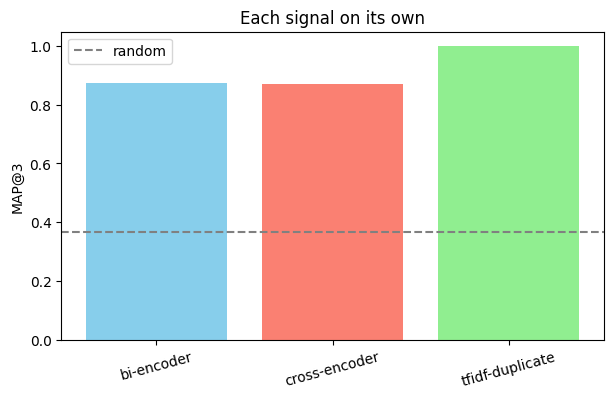

In [21]:
signals = {
    "bi-encoder": train_bi,
    "cross-encoder": train_ce,
    "tfidf-duplicate": train_tfidf,
}

print("Individual scores:")
for name, s in signals.items():
    m = all_metrics(s, y_true)
    print(f"  {name:18s} map3 {m['map3']:.4f}  acc {m['acc']:.4f}  f1 {m['f1']:.4f}")

plt.figure(figsize=(7, 4))
names = list(signals.keys())
vals = [map_at_3(s, y_true) for s in signals.values()]
plt.bar(names, vals, color=['skyblue', 'salmon', 'lightgreen'])
plt.axhline(0.3667, color='gray', linestyle='--', label='random')
plt.title("Each signal on its own")
plt.ylabel("MAP@3")
plt.xticks(rotation=15)
plt.legend()
plt.show()

In [22]:
# grid search the blend weights
best = (-1, None)
results = []

steps = np.arange(0, 1.01, 0.1)
for w1 in steps:
    for w2 in steps:
        if w1 + w2 > 1.0001:
            continue
        w3 = max(0.0, 1.0 - w1 - w2)      # max() guards against tiny negative floats
        blended = w1 * train_bi + w2 * train_ce + w3 * train_tfidf
        sc = map_at_3(blended, y_true)
        results.append({"w_bi": round(w1, 2), "w_ce": round(w2, 2),
                        "w_tfidf": round(w3, 2), "map3": sc})
        if sc > best[0]:
            best = (sc, (w1, w2, w3))

res_df = pd.DataFrame(results).sort_values("map3", ascending=False)
print("Top 10 weight combinations:")
print(res_df.head(10).to_string(index=False))

best_score, (W_BI, W_CE, W_TFIDF) = best
print()
print("Best blend MAP@3:", round(best_score, 4))
print("Weights - bi:", round(W_BI, 2), " cross:", round(W_CE, 2), " tfidf:", round(W_TFIDF, 2))

final_train = W_BI * train_bi + W_CE * train_ce + W_TFIDF * train_tfidf
m = all_metrics(final_train, y_true)
print()
print("Blended - map3:", round(m['map3'], 4), " acc:", round(m['acc'], 4),
      " f1:", round(m['f1'], 4))

Top 10 weight combinations:
 w_bi  w_ce  w_tfidf    map3
  0.1   0.2      0.7 0.99925
  0.1   0.3      0.6 0.99925
  0.3   0.0      0.7 0.99925
  0.4   0.0      0.6 0.99925
  0.1   0.1      0.8 0.99925
  0.1   0.0      0.9 0.99925
  0.3   0.1      0.6 0.99925
  0.2   0.2      0.6 0.99925
  0.2   0.1      0.7 0.99925
  0.2   0.0      0.8 0.99925

Best blend MAP@3: 0.9992
Weights - bi: 0.1  cross: 0.0  tfidf: 0.9

Blended - map3: 0.9992  acc: 0.999  f1: 0.999


**Test predictions**

In [23]:
print("Retrieving for test")
te_scores, te_idxs = retrieve(test_prompt_emb, exclude_self=False)

print("Bi-encoder signal")
test_bi = score_bi_encoder(te_scores, te_idxs, test_opt_emb)

print("Cross-encoder signal")
test_ce = score_cross_encoder(test, te_idxs, test_opt_emb)

print("TF-IDF signal")
test_tfidf = tfidf_votes(cosine_similarity(Xte, Xtr), y_true)

print()
print("All test signals ready")

Retrieving for test
Bi-encoder signal
Cross-encoder signal
Scoring 5000 prompt-document pairs with the cross-encoder


Batches:   0%|          | 0/20 [00:00<?, ?it/s]

TF-IDF signal

All test signals ready


In [24]:
final_probs = W_BI * test_bi + W_CE * test_ce + W_TFIDF * test_tfidf

top3 = np.argsort(-final_probs, axis=1)[:, :3]
predictions = [" ".join(LABELS[i] for i in row) for row in top3]

id_col = sample.columns[0]
pred_col = sample.columns[1]
submission = pd.DataFrame({id_col: test['id'].values, pred_col: predictions})
submission.to_csv("submission.csv", index=False)

print("submission.csv created, rows:", len(submission))
print(submission.head())

submission.csv created, rows: 500
   ID Prediction
0   1      A B C
1   2      B E C
2   3      B A C
3   4      E A C
4   5      C A B


**Sanity checks**

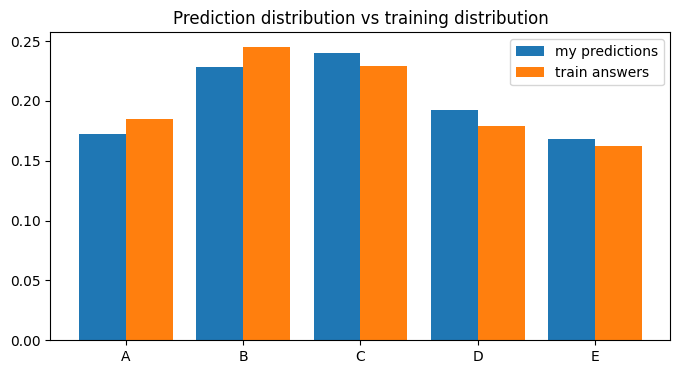

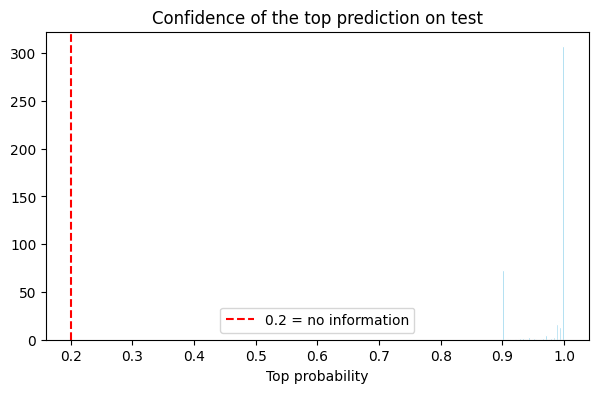

Test rows with no useful signal at all: 0 ( 0.0 % )
Those rows are effectively guesses, so they cap the achievable score.


In [25]:
r1 = pd.Series([p.split()[0] for p in predictions]).value_counts().reindex(LABELS, fill_value=0)
tr_dist = train['answer'].value_counts().reindex(LABELS, fill_value=0)

x = np.arange(5)
plt.figure(figsize=(8, 4))
plt.bar(x - 0.2, r1.values / r1.sum(), width=0.4, label='my predictions')
plt.bar(x + 0.2, tr_dist.values / tr_dist.sum(), width=0.4, label='train answers')
plt.xticks(x, LABELS)
plt.title("Prediction distribution vs training distribution")
plt.legend()
plt.show()

# how confident is the model
conf = final_probs.max(axis=1)
plt.figure(figsize=(7, 4))
plt.hist(conf, bins=40, color='skyblue', edgecolor='white')
plt.axvline(0.2, color='red', linestyle='--', label='0.2 = no information')
plt.title("Confidence of the top prediction on test")
plt.xlabel("Top probability")
plt.legend()
plt.show()

flat = (conf <= 0.21).sum()
print("Test rows with no useful signal at all:", flat,
      "(", round(flat / len(test) * 100, 1), "% )")
print("Those rows are effectively guesses, so they cap the achievable score.")